#instalar librerias
Instalar el módulo Pydub y demas librerias

In [2]:
# @title
! pip3 install pydub
!sudo apt update
!sudo apt install ffmpeg
!sudo apt install opus-tools
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from IPython.display import Audio, display

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [101 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,845 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,122 kB]
Get:13 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu j

**Importar los archivos de sonido**

In [1]:

n = 25  # Puedes cambiar este valor para manejar la cantidad de señales que necesites
# Decodificar cada archivo opus a wav
for i in range(1, n + 1):
    opus_file = f"/content/drive/MyDrive/carlos_{i}.opus"
    wav_file = f"/content/drive/MyDrive/carlos_{i}.wav"
    !opusdec {opus_file} {wav_file}
    #print(f"Archivo {opus_file} convertido a {wav_file}")
    opus_file = f"/content/drive/MyDrive/Cala_{i}.opus"
    wav_file = f"/content/drive/MyDrive/Cala_{i}.wav"
    !opusdec {opus_file} {wav_file}
    #print(f"Archivo {opus_file} convertido a {wav_file}")
    opus_file = f"/content/drive/MyDrive/astro_{i}.opus"
    wav_file = f"/content/drive/MyDrive/astro_{i}.wav"
    !opusdec {opus_file} {wav_file}
    #print(f"Archivo {opus_file} convertido a {wav_file}")
    opus_file = f"/content/drive/MyDrive/michelle_{i}.opus"
    wav_file = f"/content/drive/MyDrive/michelle_{i}.wav"
    !opusdec {opus_file} {wav_file}
    #print(f"Archivo {opus_file} convertido a {wav_file}")



opus_file = f"/content/drive/MyDrive/prueba_final.opus"
wav_file = f"/content/drive/MyDrive/prueba_final.wav"
!opusdec {opus_file} {wav_file}
#print(f"Archivo {opus_file} convertido a {wav_file}")

/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: command not found
/bin/bash: line 1: opusdec: comman

## 1. Carga y Discretización de la Señal de Audio

La señal de voz analógica $x(t)$ es adquirida y convertida a un dominio discreto mediante un proceso de muestreo digital a una frecuencia $f_s$. La señal resultante se representa como un vector discreto de $N$ muestras:

$$x[n] = [x[0], x[1], x[2], \dots, x[N-1]]$$

donde:
* **$x[n]$:** Representa la amplitud de la señal en la $n$-ésima muestra discreta.
* **$n$:** Índice de tiempo discreto ($n = 0, 1, \dots, N-1$).
* **$t_n = n \cdot T_s = \frac{n}{f_s}$:** Instante de tiempo continuo correspondiente a la muestra $n$.
* **$N$:** Número total de muestras procesadas en la ventana de audio.

# **filtrado de la señal**

La señal de voz continua es discretizada mediante muestreo digital. A continuación, se aplica la Transformada de Fourier para analizar su respuesta espectral e identificar las frecuencias dominantes ($\omega_0$). Con base en este comportamiento espectral, se aplica un filtro digital pasabanda (Butterworth) para eliminar ruido de baja y alta frecuencia, optimizando la extracción de características representativas antes de la clasificación.

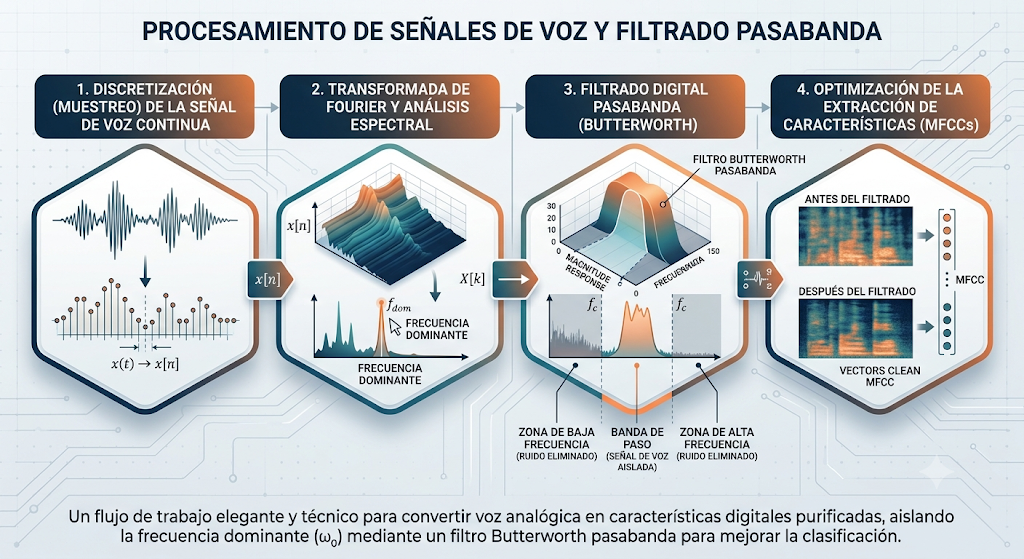


## 2. Ventaneo:
Dividimos la señal en ventanas pequeñas de longitud $ N_w $, de forma que cada ventana es tratada independientemente.



## 3. Transformada de Fourier (FFT):
Aplicamos la FFT para convertir la señal del dominio del tiempo al dominio de la frecuencia:

$$
X(f) = \sum_{n=0}^{N_w-1} x_n e^{-j 2\pi f n / N_w}
$$


## 4. Escala Mel:
La frecuencia se mapea a la escala Mel utilizando la fórmula:

$$
m(f) = 2595 \log_{10}\left( 1 + \frac{f}{700} \right)
$$

## 5. Filtrado con Filtros Mel
Luego, la señal espectral se pasa a través de una serie de **filtros Mel**. Estos filtros están diseñados para capturar las características espectrales que son más relevantes para el reconocimiento de la voz humana.

## 6. Logaritmo de la Energía:
Calculamos la energía logarítmica de cada banda Mel. La energía en la banda Mel $ m $ es:

$$
E_m = \log |X_m(f)|
$$


## 7. Transformada Discreta del Coseno (DCT):
Aplicamos la DCT para obtener los coeficientes cepstrales, los **MFCCs**. La fórmula para los MFCCs es:

$$
MFCC_k = \sum_{m=1}^{M} E_m \cos\left( \frac{\pi k (2m+1)}{2M} \right)
$$

donde $ E_m $ es la energía de la banda Mel $ m $, y $ M $ es el número total de filtros Mel.

## 8. Promediado de los MFCCs:
Se realiza un promedio movil de los **MFCCs** a lo largo de todas las ventanas de la señal para obtener un vector de características de longitud fija:

$$
MFCC = \frac{1}{T} \sum_{t=1}^{T} MFCC_t
$$

donde $ T $ es el número total de ventanas.

# Proyecto funcional

$extract  features$

Especifica que queremos extraer 13 coeficientes MFCC, que son los más comunes y los que suelen capturar las características más relevantes de la voz.

In [3]:
# Función para extraer MFCCs y características
def extract_features(signal, sample_rate):
    # Extraer MFCCs
    mfccs = librosa.feature.mfcc(y=signal, sr=sample_rate, n_mfcc=15)
    mfccs = np.mean(mfccs.T, axis=0)  # Promedio de MFCCs para cada archivo
    return mfccs


Los MFCCs se calculan mediante un proceso que involucra la FFT (Transformada Rápida de Fourier), la aplicación de filtros Mel, y luego una Transformada Discreta del Coseno (DCT) sobre la energía logarítmica obtenida de las bandas Mel.

Devuelve el vector promedio de los MFCCs, que luego puede ser utilizado como entrada para un modelo de aprendizaje automático (por ejemplo, un clasificador como SVM).

# Parametros de la señal

In [4]:
sample_rate = 16000  # frecuencia de muestreo de 16 kHz
audio_paths = []
labels = []

*   Toma los datos del banco

In [8]:
# Crear una lista de archivos y etiquetas para los 4 hablantes (25 archivos por hablante)
for i in range(1, 26):

    # Añadir las rutas de los archivos para cada hablante
    audio_paths.append(f"/content/drive/MyDrive/carlos_{i}.wav")
    labels.append('Carlos')
    audio_paths.append(f"/content/drive/MyDrive/astro_{i}.wav")
    labels.append('Astro')
    audio_paths.append(f"/content/drive/MyDrive/Cala_{i}.wav")
    labels.append('Cala')
    audio_paths.append(f"/content/drive/MyDrive/michelle_{i}.wav")
    labels.append('Mich')

In [9]:
# Extraer características de cada archivo de audio
features = []
#print(lengh(audio_paths))
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)  # Codificar las etiquetas de los hablantes

# Extraer los MFCCs para cada archivo
for audio_path in audio_paths:
    signal, _ = librosa.load(audio_path, sr=sample_rate)
    mfcc_features = extract_features(signal, sample_rate)
    features.append(mfcc_features)

features = np.array(features)

In [ ]:
print(features[0])

[-166.54459     123.33643      -6.8440013    10.123174    -22.518559
   -6.847593    -21.615978     -9.887478    -20.511356     -8.169936
  -16.256676      0.79694057  -13.7405405     1.0456525   -11.768219  ]


# Entrenamiento y datos de prueba

test_size=0.4

In [10]:
# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(features, encoded_labels, test_size=0.7, stratify=encoded_labels)
print('Entrenamiento: ',X_train.shape)
print('Prueba: ',X_test.shape)

# Entrenamiento de un clasificador SVM
model = SVC(kernel='linear', probability=True)
model.fit(X_train, y_train)

Entrenamiento:  (60, 15)
Prueba:  (140, 15)


SVC(kernel='linear', probability=True)

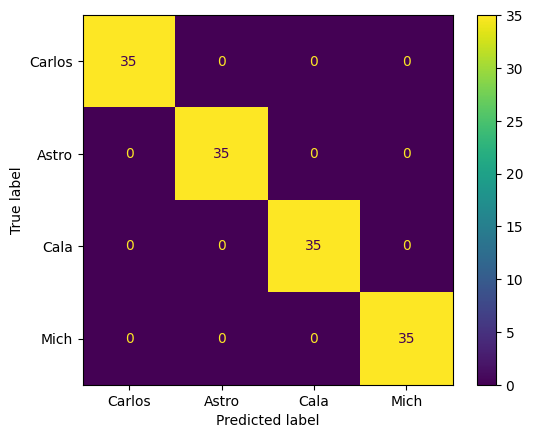

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Etiquetas de las clases (en el orden que corresponden a tu modelo)
class_labels = ['Carlos', 'Astro', 'Cala', 'Mich']

# Predecir las etiquetas para el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión con títulos
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='viridis')  # Puedes cambiar 'viridis' por otro colormap si lo deseas


In [12]:
def predict_speaker(input_audio_path):
    signal, _ = librosa.load(input_audio_path, sr=sample_rate)
    mfcc_features = extract_features(signal, sample_rate)

    # Predecir la probabilidad para cada clase (hablante)
    probs = model.predict_proba([mfcc_features])[0]

    # Mostrar los porcentajes de probabilidad de cada hablante
    print(f"Probabilidades para el archivo {input_audio_path}:")
    for i, label in enumerate(label_encoder.classes_):
        print(f"{label}: {probs[i] * 100:.2f}%")

    # Obtener el índice del hablante con la probabilidad máxima
    max_index = probs.argmax()

    # Mostrar el hablante con la mayor probabilidad
    print(f'El hablante es: {label_encoder.classes_[max_index]}')

# Probar con un archivo de entrada (voz desconocida)
input_audio = "/content/drive/MyDrive/prueba_final.wav"  # Archivo de entrada
predict_speaker(input_audio)

Probabilidades para el archivo /content/drive/MyDrive/prueba_final.wav:
Astro: 58.19%
Cala: 25.72%
Carlos: 1.52%
Mich: 14.58%
El hablante es: Astro


# Datos de entrenamiento

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Crear las listas de archivos y etiquetas
audio_paths = []
labels = []

for i in range(1, 26):
    audio_paths.append(f"/content/drive/MyDrive/carlos_{i}.wav")
    labels.append('Carlos')
    audio_paths.append(f"/content/drive/MyDrive/astro_{i}.wav")
    labels.append('Astro')
    audio_paths.append(f"/content/drive/MyDrive/Cala_{i}.wav")
    labels.append('Cala')
    audio_paths.append(f"/content/drive/MyDrive/michelle_{i}.wav")
    labels.append('Mich')

# Codificar las etiquetas
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

# Simulación de extracción de características (reemplaza esto con tu `extract_features`)
features = np.random.rand(len(audio_paths), 13)  # 13 características MFCC simuladas

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test, train_indices, test_indices = train_test_split(
    features, encoded_labels, range(len(audio_paths)), test_size=0.7, stratify=encoded_labels)

# Ordenar los índices de entrenamiento
train_indices_sorted = sorted(train_indices)

# Imprimir los nombres de los audios utilizados en el entrenamiento en orden
print("Audios utilizados para entrenamiento (en orden):")
for idx in train_indices_sorted:
    print(f"Archivo: {audio_paths[idx]}, Etiqueta: {labels[idx]}")

print("Número de archivos de entrenamiento:", len(train_indices))

Audios utilizados para entrenamiento (en orden):
Archivo: /content/drive/MyDrive/carlos_2.wav, Etiqueta: Carlos
Archivo: /content/drive/MyDrive/Cala_2.wav, Etiqueta: Cala
Archivo: /content/drive/MyDrive/carlos_3.wav, Etiqueta: Carlos
Archivo: /content/drive/MyDrive/astro_4.wav, Etiqueta: Astro
Archivo: /content/drive/MyDrive/michelle_4.wav, Etiqueta: Mich
Archivo: /content/drive/MyDrive/Cala_5.wav, Etiqueta: Cala
Archivo: /content/drive/MyDrive/Cala_6.wav, Etiqueta: Cala
Archivo: /content/drive/MyDrive/michelle_6.wav, Etiqueta: Mich
Archivo: /content/drive/MyDrive/carlos_7.wav, Etiqueta: Carlos
Archivo: /content/drive/MyDrive/Cala_7.wav, Etiqueta: Cala
Archivo: /content/drive/MyDrive/michelle_7.wav, Etiqueta: Mich
Archivo: /content/drive/MyDrive/carlos_8.wav, Etiqueta: Carlos
Archivo: /content/drive/MyDrive/michelle_8.wav, Etiqueta: Mich
Archivo: /content/drive/MyDrive/astro_9.wav, Etiqueta: Astro
Archivo: /content/drive/MyDrive/astro_10.wav, Etiqueta: Astro
Archivo: /content/drive/MyD